## Loading

Importing modules	

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [3]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True
)

In [4]:
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    download = True
)

In [5]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [7]:
print(train_data.data.shape)
print(test_data.data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


## EDA

### 2. Dataset Overview

In [8]:
print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples: {len(test_data)}")

# Looking at an example of what a single data point look
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Number of training samples: 60000
Number of test samples: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5


### 3. Visualizing Random Samples

Here i have visualized a few handwritten digits from the training set.  

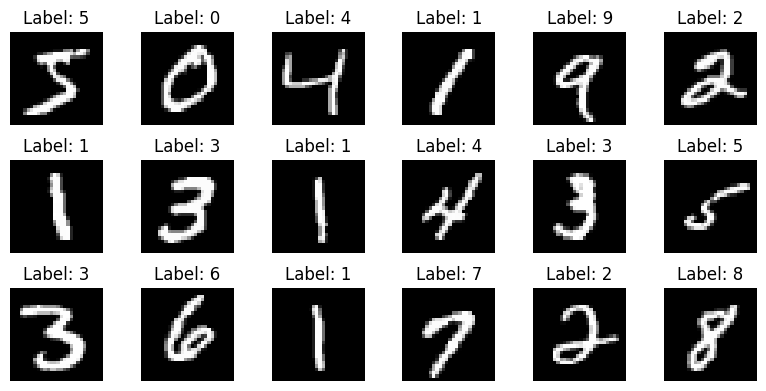

In [9]:
# Visualize a few random samples from the training data
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(3, 6, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 4. Number Distribution in this Set

This histo shows how many samples exist for each digit (0–9).

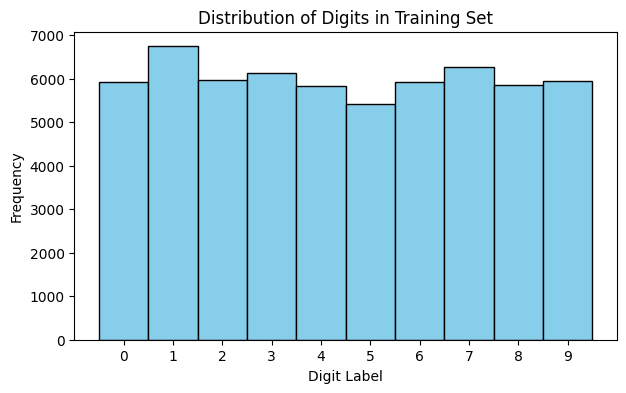

In [10]:
# Extract all labels
labels = [label for _, label in train_data]

# Plottin label frequency
plt.figure(figsize=(7, 4))
plt.hist(labels, bins=np.arange(11) - 0.5, edgecolor='black', color='skyblue')
plt.xticks(range(10))
plt.xlabel('Digit Label')
plt.ylabel('Frequency')
plt.title('Distribution of Digits in Training Set')
plt.show()

### 5. Pixel Intensity Distribution

Here pixel values range from **0 to 1** because of the `ToTensor()` transform, which scales raw pixel values from 0–255 to 0–1.

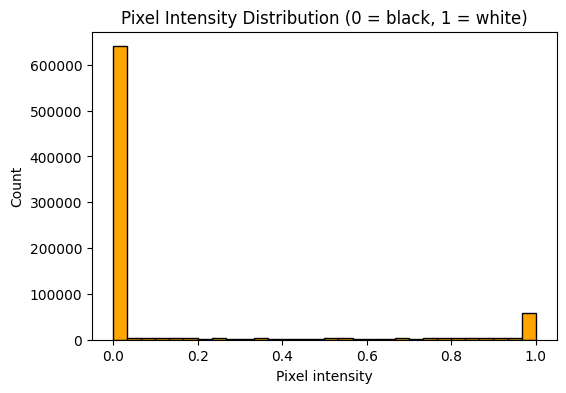

In [11]:
import torch
# Combining a small batch of images into a single tensor
images = torch.stack([train_data[i][0] for i in range(1000)])  # sample 1000 images
pixels = images.view(-1).numpy()

plt.figure(figsize=(6, 4))
plt.hist(pixels, bins=30, color='orange', edgecolor='black')
plt.title("Pixel Intensity Distribution (0 = black, 1 = white)")
plt.xlabel("Pixel intensity")
plt.ylabel("Count")
plt.show()

- Most pixels are **dark (near 0)**, indicating that digits are written on a black background.  
- A smaller peak near **1** corresponding to possibly the  white strokes of digits.  
This confirms that the dataset is grayscale

### 6. Checking for Blanks or Corrupted Images

Verifying if there are any completely blank or corrupted images.  

In [12]:
# Checking if any images are completely blank/corrupted
blank_images = sum([torch.sum(img)==0 for img, _ in train_data])
print(f"Number of completely blank images: {blank_images}")

Number of completely blank images: 0


## Modelling

In [13]:
from torch.utils.data import DataLoader

#### DataLoader


A **DataLoader** automates how data is fed into the model.  
It:
- Breaks the dataset into **mini-batches** (smaller chunks)
- **Shuffles** the order of data each epoch (to avoid learning the order)
- Loads data using **parallel workers** to improve speed

This allows the model to train efficiently without having to load all 60,000 images into memory at once.


In [14]:
loaders = {
    'train': DataLoader(
        train_data,
        batch_size=100,
        shuffle=True,
        num_workers=1
    ),
    'test': DataLoader(
        test_data,
        batch_size=100,
        shuffle=True,
        num_workers=1
    ),
}

In [15]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x302b80560>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x177f60920>}

### Building the CNN



In [16]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Defining the CNN
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # 1st convolutional layer: input channels = 1 (grayscale), output channels = 10, kernel size = 5x5
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        
        self.conv2_drop = nn.Dropout2d()
        
        self.fc1 = nn.Linear(320, 50)   
        self.fc2 = nn.Linear(50, 10)    

    def forward(self, x):
        
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        
       
        x = x.view(-1, 320)
        
        
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        
        
        x = self.fc2(x)
        return x

## Model Training and Evaluation Setup

⚙️ 1. Device Setup

To utilize hardware acceleration, we check for available devices in this order:
1. **MPS (Metal Performance Shaders)** → for Apple Silicon GPUs (M1/M2/M3)
2. **CUDA** → for NVIDIA GPUs
3. **CPU** → fallback option

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

# ✅ Device Setup (CPU / CUDA / MPS)
if torch.backends.mps.is_available():
    device = torch.device("mps")           
elif torch.cuda.is_available():
    device = torch.device("cuda")          
else:
    device = torch.device("cpu")           

print(f"Using device: {device}")

Using device: mps


In [18]:
# Initializing model, optimizer, and loss func
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

#### Training Function


In [19]:
def train(epoch):
    model.train() 
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = loss_fn(output, target)

        loss.backward()

        optimizer.step()

        if batch_idx % 20 == 0:
            print(f'Train Epoch: {epoch} '
                  f'[{batch_idx * len(data)}/{len(loaders["train"].dataset)} '
                  f'({100. * batch_idx / len(loaders["train"]):.0f}%)]\tLoss: {loss.item():.6f}')

#### 🔁 Testing Function

In [20]:
def test():
    model.eval()  
    test_loss = 0
    correct = 0

    with torch.no_grad():  
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()

            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

   
    test_loss /= len(loaders['test'].dataset)

    print(f'\nTest set: Average loss: {test_loss:.4f}, '
          f'Accuracy: {correct}/{len(loaders["test"].dataset)} '
          f'({100. * correct / len(loaders["test"].dataset):.0f}%)\n')

In [21]:
for epoch in range (1,11):
    train(epoch),
    test()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.307615
Train Epoch: 1 [2000/60000 (3%)]	Loss: 2.264360
Train Epoch: 1 [4000/60000 (7%)]	Loss: 1.934789
Train Epoch: 1 [6000/60000 (10%)]	Loss: 1.334517
Train Epoch: 1 [8000/60000 (13%)]	Loss: 0.968099
Train Epoch: 1 [10000/60000 (17%)]	Loss: 0.832070
Train Epoch: 1 [12000/60000 (20%)]	Loss: 0.809115
Train Epoch: 1 [14000/60000 (23%)]	Loss: 0.936653
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.713952
Train Epoch: 1 [18000/60000 (30%)]	Loss: 0.664545
Train Epoch: 1 [20000/60000 (33%)]	Loss: 0.626357
Train Epoch: 1 [22000/60000 (37%)]	Loss: 0.588699
Train Epoch: 1 [24000/60000 (40%)]	Loss: 0.625351
Train Epoch: 1 [26000/60000 (43%)]	Loss: 0.666087
Train Epoch: 1 [28000/60000 (47%)]	Loss: 0.409092
Train Epoch: 1 [30000/60000 (50%)]	Loss: 0.594023
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.584767
Train Epoch: 1 [34000/60000 (57%)]	Loss: 0.626320
Train Epoch: 1 [36000/60000 (60%)]	Loss: 0.482304
Train Epoch: 1 [38000/60000 (63%)]	Loss: 0.487425
Train Epoch

### Evalutuon

Prediction: 7


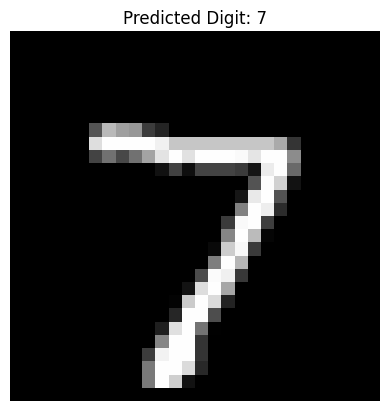

In [22]:
model.eval()

data, target = test_data[0]

data = data.unsqueeze(0).to(device)


output = model(data)

# Geting the predicted digit
prediction = output.argmax(dim=1, keepdim=True).item()

print(f'Prediction: {prediction}')

# Convert image tensor back to numpy
image = data.squeeze(0).squeeze(0).cpu().numpy()

# Ploting the img
plt.imshow(image, cmap='gray')
plt.title(f'Predicted Digit: {prediction}')
plt.axis('off')
plt.show()

In [23]:
# Save
torch.save(model.state_dict(), "mnist_cnn.pt")

# Quick check if the file exists
import os; print(os.path.getsize("mnist_cnn.pt"), "bytes")

90793 bytes
